# Soderberg 1986 composite preset demo

This notebook demonstrates the `Soderberg1986Pipeline`, which keeps the regeneration + young-stand + mortality + valuation workflow from the Elfving preset but uses **Soderberg (1986)** for mature-tree DBH growth.

It also reports `qmd_cm` and `hq_m` in each projection step.

In [1]:
import matplotlib.pyplot as plt

from pyforestry.base.helpers.primitives import SiteBase
from pyforestry.sweden.simulation.presets import (
    Soderberg1986PipelineConfig,
    build_soderberg_1986_pipeline,
)
from pyforestry.sweden.site import Sweden, SwedishSite
from pyforestry.sweden.siteindex.sis.generated_site_category_trees import (
    predict_site_categories_county_tree,
)
from pyforestry.sweden.siteindex.sis.hagglund_lundmark_1977 import Hagglund_Lundmark_1977_SIS


In [2]:
class SwedishSiteDemo(SwedishSite):
    """Concrete wrapper for notebooks (implements SiteBase abstract method)."""

    def compute_attributes(self) -> None:
        SwedishSite.__post_init__(self)

    def __post_init__(self) -> None:
        SiteBase.__post_init__(self)

In [3]:
requested_sis = 20.0
site_category_species = "Pinus sylvestris"
county = Sweden.County.KOPPARBERG_OVRIGA

predicted_site_categories = predict_site_categories_county_tree(
    sis_hagglund_1979=requested_sis,
    species=site_category_species,
    Direktlan=county,
)

site = SwedishSiteDemo(
    latitude=60.5,
    longitude=15.0,
    altitude=150.0,
    field_layer=predicted_site_categories["field_layer"],
    bottom_layer=predicted_site_categories["bottom_layer"],
    soil_texture=predicted_site_categories["soil_texture"],
    soil_moisture=predicted_site_categories["soil_moisture"],
    soil_depth=predicted_site_categories["soil_depth"],
    soil_water=predicted_site_categories["soil_water"],
    ditched=predicted_site_categories["ditched"],
)

achieved_sis = Hagglund_Lundmark_1977_SIS(
    species=site_category_species,
    latitude=site.latitude,
    altitude=site.altitude or 0.0,
    soil_moisture=site.soil_moisture,
    ground_layer=site.bottom_layer or Sweden.BottomLayer.FRESH_MOSS,
    vegetation=site.field_layer,
    soil_texture=site.soil_texture or Sweden.SoilTextureTill.SANDY,
    climate_code=site.climate_zone or Sweden.ClimateZone.K1,
    lateral_water=site.soil_water or Sweden.SoilWater.SELDOM_NEVER,
    soil_depth=site.soil_depth or Sweden.SoilDepth.DEEP,
    incline_percent=site.incline_percent or 0.0,
    aspect=site.aspect or 0.0,
    nfi_adjustments=True,
    dlan=site.county or county,
    ditched=bool(site.ditched),
    peat=False,
    gotland=False,
    coast=(site.distance_to_coast or 9999.0) < 50.0,
    limes_norrlandicus=bool(site.n_of_limes_norrlandicus),
)

sis_closeness = {
    "requested_sis": requested_sis,
    "achieved_sis": float(achieved_sis),
    "sis_abs_error": abs(float(achieved_sis) - requested_sis),
    "sis_rel_error_pct": 100.0 * abs(float(achieved_sis) - requested_sis) / requested_sis,
}

display({"sis_closeness": sis_closeness, "predicted_site_categories": predicted_site_categories})

config = Soderberg1986PipelineConfig(
    sample_trees=120,
    random_seed=2026,
    deterministic=True,
    dt_years=5.0,
)
preset = build_soderberg_1986_pipeline(config)
preset

{'sis_closeness': {'requested_sis': 20.0,
  'achieved_sis': 20.698654683125625,
  'sis_abs_error': 0.6986546831256248,
  'sis_rel_error_pct': 3.493273415628124},
 'predicted_site_categories': {'field_layer': <SwedenFieldLayer.LICHEN_FREQUENT: Vegetation(code=17, swedish_name='Lavrik', english_name='Lichen, frequent occurrence', index=-0.5)>,
  'bottom_layer': <SwedenBottomLayer.BOGMOSS_TYPE: BottomLayerType(code=4, english_name='Bogmoss type (Sphagnum)', swedish_name='Vitmosstyp')>,
  'soil_texture': <SwedenSoilTextureTill.SANDY_MOIG: SoilTextureCategory(code=4, swedish_name='Sandig-moig morän', english_name='Sandy-silty till', short_name='Medium sand')>,
  'soil_moisture': <SwedenSoilMoisture.MESIC: SoilMoistureData(code=2, swedish_description='frisk', english_description='Mesic (subsoil water depth = 1-2 m)')>,
  'soil_depth': <SwedenSoilDepth.DEEP: SoilDepthCat(code=1, swedish_description='Mäktigt >70 cm. Inga synliga hällar', english_description='Deep >70cm. No visible stone outcro

In [4]:
results = preset.run_projection(site=site, n_steps=30)
results

/home/runner/work/pyforestry/pyforestry/src/pyforestry/sweden/simulation/mortality/engine.py:452: UserWarning: Soderberg self-thinning annual probability exceeded [0, 1]; clamped.
  probabilities, adjusted, factors, diag = calibrate_soderberg(


,step_index,age_years,years_elapsed,stems_per_ha,mean_dbh_cm,mean_height_m,qmd_cm,hq_m,basal_area_m2_ha,standing_volume_m3sk_per_ha,...,birch_ba_share,handover_dbh_cm,handover_mean_height_m,handover_smoothing_width_m,phase_over_weight,young_damage_index_mean,young_damage_mortality_stems_removed_per_ha,mortality_fraction_mean,mortality_stems_removed_per_ha,young_stand_potential_q
0,0.0,12.0,0.0,6244.836223,1.016164,1.715820,1.684151,3.064966,1.391148,4.292985,...,0.307493,10.0,7.0,1.0,0.023479,0.000000,0.000000,0.000000,0.000000,77.405649
1,1.0,17.0,5.0,5887.431819,3.373596,2.804763,4.696728,4.211589,10.200150,33.834751,...,0.458221,10.0,7.0,1.0,0.019741,0.334118,357.404404,0.000000,0.000000,77.405649
2,2.0,22.0,10.0,5499.208242,4.615034,3.919477,6.362217,6.038806,17.482637,71.296407,...,0.414063,10.0,7.0,1.0,0.058055,0.309568,288.794491,0.032829,99.429086,77.405649
3,3.0,27.0,15.0,5084.802155,5.556470,4.934087,7.677256,7.882106,23.538348,114.949419,...,0.399718,10.0,7.0,1.0,0.148796,0.290809,257.924056,0.055494,156.482031,77.405649
4,4.0,32.0,20.0,4705.641512,6.203203,5.389893,8.578298,9.114058,27.196372,143.155275,...,0.390548,10.0,7.0,1.0,0.194099,0.341270,202.933136,0.066187,176.227507,77.405649
5,5.0,37.0,25.0,4307.224024,6.768155,5.962535,9.285682,9.803689,29.168558,165.199010,...,0.393291,10.0,7.0,1.0,0.251268,0.463665,225.047761,0.071493,173.369728,77.405649
6,6.0,42.0,30.0,3936.774729,7.287962,6.469048,9.919011,10.499224,30.420559,182.264489,...,0.395706,10.0,7.0,1.0,0.377420,0.477029,206.776141,0.073884,163.673154,77.405649
7,7.0,47.0,35.0,3596.678361,7.783706,6.930908,10.506292,11.094284,31.181026,195.363627,...,0.397434,10.0,7.0,1.0,0.505314,0.491090,188.403721,0.074936,151.692646,77.405649
8,8.0,52.0,40.0,3287.329031,8.266876,7.361355,11.063079,11.611386,31.599855,205.332663,...,0.398452,10.0,7.0,1.0,0.621156,0.505849,170.305820,0.074843,139.043510,77.405649
9,9.0,57.0,45.0,3007.777677,8.734517,7.759863,11.585687,12.061089,31.708758,212.142586,...,0.397483,10.0,7.0,1.0,0.717468,0.521320,152.786107,0.073910,126.765247,77.405649


In [5]:
results[[
    "step_index",
    "age_years",
    "stems_per_ha",
    "qmd_cm",
    "hq_m",
    "mean_dbh_cm",
    "mean_height_m",
    "basal_area_m2_ha",
    "standing_volume_m3sk_per_ha",
    "standing_value_sek_per_ha",
]]

,step_index,age_years,stems_per_ha,qmd_cm,hq_m,mean_dbh_cm,mean_height_m,basal_area_m2_ha,standing_volume_m3sk_per_ha,standing_value_sek_per_ha
0,0.0,12.0,6244.836223,1.684151,3.064966,1.016164,1.715820,1.391148,4.292985,0.000000
1,1.0,17.0,5887.431819,4.696728,4.211589,3.373596,2.804763,10.200150,33.834751,1372.304092
2,2.0,22.0,5499.208242,6.362217,6.038806,4.615034,3.919477,17.482637,71.296407,12692.054898
3,3.0,27.0,5084.802155,7.677256,7.882106,5.556470,4.934087,23.538348,114.949419,20775.844321
4,4.0,32.0,4705.641512,8.578298,9.114058,6.203203,5.389893,27.196372,143.155275,26233.018062
5,5.0,37.0,4307.224024,9.285682,9.803689,6.768155,5.962535,29.168558,165.199010,31530.603910
6,6.0,42.0,3936.774729,9.919011,10.499224,7.287962,6.469048,30.420559,182.264489,36919.740421
7,7.0,47.0,3596.678361,10.506292,11.094284,7.783706,6.930908,31.181026,195.363627,42254.780825
8,8.0,52.0,3287.329031,11.063079,11.611386,8.266876,7.361355,31.599855,205.332663,43805.791507
9,9.0,57.0,3007.777677,11.585687,12.061089,8.734517,7.759863,31.708758,212.142586,45463.319060


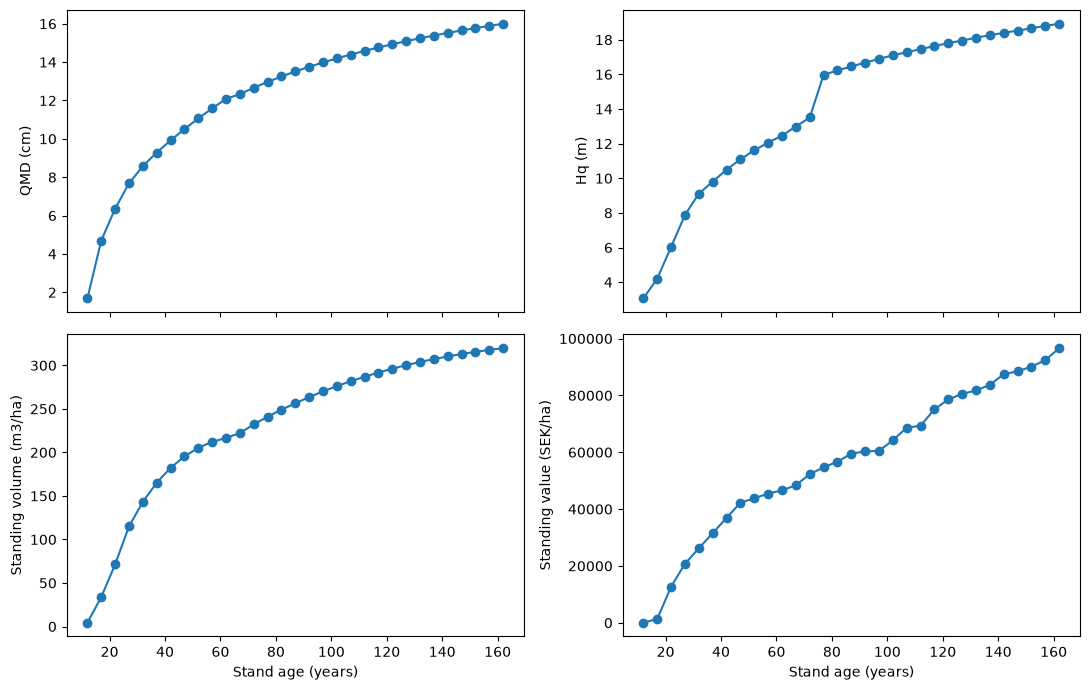

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
axes = axes.flatten()

axes[0].plot(results["age_years"], results["qmd_cm"], marker="o")
axes[0].set_ylabel("QMD (cm)")

axes[1].plot(results["age_years"], results["hq_m"], marker="o")
axes[1].set_ylabel("Hq (m)")

axes[2].plot(results["age_years"], results["standing_volume_m3sk_per_ha"], marker="o")
axes[2].set_ylabel("Standing volume (m3/ha)")
axes[2].set_xlabel("Stand age (years)")

axes[3].plot(results["age_years"], results["standing_value_sek_per_ha"], marker="o")
axes[3].set_ylabel("Standing value (SEK/ha)")
axes[3].set_xlabel("Stand age (years)")

plt.tight_layout()

## Notes

- Mature-tree growth in this preset comes from `Soderberg1986Model`.
- Unlike Elfving 2010, there is no stand-level basal-area correction stage in the mature-growth model.